# Avance 2. Ingeniería de características

## Equipo 41

**Proyecto:** Detección de ocultamiento de mercancía en video para retail

### Objetivo

Este notebook documenta el proceso de ingeniería de características realizado sobre los datos utilizados en el proyecto integrador. El trabajo incluye la construcción de un conjunto consolidado de clips de video, la generación de variables derivadas para describir sus propiedades, el análisis de diferencias entre fuentes, la identificación de posibles características sesgadas y la preparación de la variable objetivo para un problema de clasificación binaria.

Debido a que los datos principales del proyecto son videos, las operaciones de ingeniería de características se adaptan a una unidad de análisis temporal. En esta etapa se trabaja con clips provenientes de diferentes fuentes y se conservan características relacionadas con su origen, duración, etiqueta y elegibilidad para los experimentos posteriores.

## 1.1 Fuentes incluidas en el dataset consolidado

Para los experimentos basados en información RGB se consolidaron clips provenientes de cuatro fuentes:

- **CCTV_YOLO**
- **DCSASS** (Anomaly Detection Dataset UCF)
- **MNNIT**
- **SINTETICO**

Cada fuente presenta diferencias en duración, distribución de clases y forma de organización de los videos. Por esta razón, antes de aplicar normalización o preparar los datos para entrenamiento, se conservó la trazabilidad de cada clip mediante su dataset de origen, identificador de video, identificador de clip y etiqueta.

El dataset **RetailS** no se incluye en esta consolidación porque contiene información de pose corporal y será utilizado posteriormente en un enfoque independiente basado en puntos corporales.

También se conservaron en las fuentes originales los clips con etiquetas que no forman parte del problema binario de clasificación, como `no_determinado` o `ambiguo`. Estos registros pueden ser útiles para análisis posteriores, pero no se asignan automáticamente a las clases `ocultamiento` o `sin_ocultamiento`.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# Directorio de trabajo para la preparación de datos
BASE_DIR = Path(
    "/opt/workspace/MNA---Proyecto-Integrador/"
    "Datos/Preparacion_Datasets"
)

# Archivos generados durante la preparación
MANIFEST_PATH = BASE_DIR / "dataset_manifest_todos.csv"

FEATURES_PATH = (
    BASE_DIR / "dataset_consolidado_features.csv"
)

DURACIONES_PATH = (
    BASE_DIR / "duraciones_dataset_consolidado.csv"
)

# Dataset físico consolidado
CLIPS_DIR = Path(
    "/opt/workspace/datasets/procesados/clips_4s"
)

print("Manifest disponible:    ", MANIFEST_PATH.exists())
print("Features disponibles:    ", FEATURES_PATH.exists())
print("Duraciones disponibles:  ", DURACIONES_PATH.exists())
print("Directorio de clips:     ", CLIPS_DIR.exists())

Manifest disponible:     True
Features disponibles:     True
Duraciones disponibles:   True
Directorio de clips:      True


In [2]:
df = pd.read_csv(FEATURES_PATH)

print(f"Registros del dataset consolidado: {len(df)}")
print(f"Columnas disponibles: {len(df.columns)}")

df.head()

Registros del dataset consolidado: 987
Columnas disponibles: 19


,dataset,video_id,video_origen,clip_id,inicio_s,fin_s,etiqueta,persona_id,evento_id,nota,nombre_clip,duracion_real_s,duracion_objetivo_s,diferencia_vs_4s,cumple_4s,requiere_normalizacion_temporal,elegible_modelo_binario,motivo_no_elegible,clase_binaria
0,CCTV_YOLO,CCTV_001,not_shoplifting1.mp4,CCTV_001,2.0,6.0,sin_ocultamiento,P001_AJ,NaN,NaN,CCTV_YOLO__CCTV_001__CCTV_001.mp4,4.0,4.0,0.0,True,False,True,NaN,0.0
1,CCTV_YOLO,CCTV_002,not_shoplifting2.mp4,CCTV_002,2.0,6.0,sin_ocultamiento,P002_AJ,NaN,NaN,CCTV_YOLO__CCTV_002__CCTV_002.mp4,4.0,4.0,0.0,True,False,True,NaN,0.0
2,CCTV_YOLO,CCTV_003,not_shoplifting3.mp4,CCTV_003,2.0,6.0,sin_ocultamiento,P003_AJ,NaN,NaN,CCTV_YOLO__CCTV_003__CCTV_003.mp4,4.0,4.0,0.0,True,False,True,NaN,0.0
3,CCTV_YOLO,CCTV_004,not_shoplifting4.mp4,CCTV_004,2.0,6.0,sin_ocultamiento,P004_AJ,NaN,NaN,CCTV_YOLO__CCTV_004__CCTV_004.mp4,4.0,4.0,0.0,True,False,True,NaN,0.0
4,CCTV_YOLO,CCTV_005,shoplifting1.mp4,CCTV_005,2.0,6.0,ocultamiento,P001_AJ,NaN,NaN,CCTV_YOLO__CCTV_005__CCTV_005.mp4,4.0,4.0,0.0,True,False,True,NaN,1.0


In [3]:
conteo_por_dataset = (
    df["dataset"]
    .value_counts()
    .rename_axis("dataset")
    .reset_index(name="clips")
)

conteo_por_dataset["porcentaje"] = (
    conteo_por_dataset["clips"]
    / len(df)
    * 100
).round(2)

conteo_por_dataset

,dataset,clips,porcentaje
0,DCSASS,783,79.33
1,MNNIT,182,18.44
2,SINTETICO,14,1.42
3,CCTV_YOLO,8,0.81


### 1.2 Composición del dataset consolidado

El dataset consolidado contiene **987 clips** provenientes de cuatro fuentes. DCSASS aporta la mayor cantidad de observaciones, con 783 clips, equivalentes al 79.33% del total. MNNIT representa el 18.44%, mientras que CCTV_YOLO y SINTETICO tienen una participación considerablemente menor.

Esta distribución muestra que las fuentes no contribuyen de manera uniforme al conjunto consolidado. Por esta razón, la variable `dataset` se conserva como una característica de control y trazabilidad. No se utilizará directamente como entrada del modelo, pero permitirá analizar posteriormente si el desempeño está condicionado por características propias de alguna fuente.

In [4]:
archivos_fisicos = {
    p.name
    for p in CLIPS_DIR.glob("*.mp4")
    if p.is_file()
}

clips_manifestados = set(
    df["nombre_clip"]
    .dropna()
    .astype(str)
    .str.strip()
)

faltantes = sorted(
    clips_manifestados - archivos_fisicos
)

extras = sorted(
    archivos_fisicos - clips_manifestados
)

print(f"Clips esperados en el consolidado: {len(clips_manifestados)}")
print(f"Archivos MP4 encontrados:          {len(archivos_fisicos)}")
print(f"Archivos faltantes:                {len(faltantes)}")
print(f"Archivos extras:                   {len(extras)}")

Clips esperados en el consolidado: 987
Archivos MP4 encontrados:          987
Archivos faltantes:                0
Archivos extras:                   0


### 1.3 Validación del dataset consolidado

La validación entre el manifiesto enriquecido y los archivos físicos confirmó una correspondencia completa entre ambos. El dataset contiene **987 clips esperados y 987 archivos MP4 disponibles**, sin archivos faltantes ni archivos adicionales.

Esta verificación permite utilizar `dataset_consolidado_features.csv` como referencia para los análisis posteriores, manteniendo la trazabilidad entre cada registro tabular y su clip de video correspondiente.

### 1.4 Scripts utilizados para la preparación y validación

Las operaciones de preparación se implementaron mediante scripts independientes para mantener separado el procesamiento operativo del análisis presentado en este notebook. Los scripts se encuentran en `Datos/Preparacion_Datasets/scripts/`.

| Script | Propósito |
|---|---|
| `generar_clips_4s.py` | Generar clips a partir de CCTV_YOLO, MNNIT y SINTETICO utilizando los intervalos definidos en el manifiesto. |
| `validar_clips_4s.py` | Verificar cantidad, duración y existencia de stream de video en los clips generados. |
| `extraer_dcsass.py` | Extraer y validar la estructura de los clips DCSASS disponibles en el archivo comprimido. |
| `validar_dcsass_manifest.py` | Comprobar la correspondencia entre los archivos físicos DCSASS y los registros del manifiesto. |
| `auditar_dcsass_seleccion.py` | Analizar las etiquetas de DCSASS y determinar los clips elegibles para el problema binario. |
| `incorporar_dcsass.py` | Incorporar al dataset consolidado los clips DCSASS seleccionados por el manifiesto. |
| `validar_dataset_unificado.py` | Verificar correspondencia entre el dataset consolidado, el manifiesto y los archivos físicos, además de revisar decodificación y duración. |
| `analizar_duraciones_consolidado.py` | Medir la duración real de los clips y generar las características temporales utilizadas en el análisis. |
| `analizar_sesgo_fuente_duracion.py` | Analizar la relación entre fuente, duración y etiqueta para identificar posibles características sesgadas. |
| `crear_dataset_consolidado_features.py` | Construir `dataset_consolidado_features.csv` integrando trazabilidad y características derivadas. |
| `codificar_clase_binaria.py` | Generar la representación numérica de la variable objetivo para el problema binario. |

Esta organización permite reproducir el proceso de preparación sin duplicar en el notebook el código operacional completo. El notebook utiliza los artefactos resultantes para mostrar las validaciones, análisis y decisiones de ingeniería de características.

In [5]:
columnas_features = [
    "dataset",
    "clip_id",
    "etiqueta",
    "duracion_real_s",
    "duracion_objetivo_s",
    "diferencia_vs_4s",
    "cumple_4s",
    "requiere_normalizacion_temporal",
    "elegible_modelo_binario",
    "motivo_no_elegible",
    "clase_binaria",
]

df[columnas_features].head(10)

,dataset,clip_id,etiqueta,duracion_real_s,duracion_objetivo_s,diferencia_vs_4s,cumple_4s,requiere_normalizacion_temporal,elegible_modelo_binario,motivo_no_elegible,clase_binaria
0,CCTV_YOLO,CCTV_001,sin_ocultamiento,4.0,4.0,0.0,True,False,True,NaN,0.0
1,CCTV_YOLO,CCTV_002,sin_ocultamiento,4.0,4.0,0.0,True,False,True,NaN,0.0
2,CCTV_YOLO,CCTV_003,sin_ocultamiento,4.0,4.0,0.0,True,False,True,NaN,0.0
3,CCTV_YOLO,CCTV_004,sin_ocultamiento,4.0,4.0,0.0,True,False,True,NaN,0.0
4,CCTV_YOLO,CCTV_005,ocultamiento,4.0,4.0,0.0,True,False,True,NaN,1.0
5,CCTV_YOLO,CCTV_006,ocultamiento,4.0,4.0,0.0,True,False,True,NaN,1.0
6,CCTV_YOLO,CCTV_007,ocultamiento,4.0,4.0,0.0,True,False,True,NaN,1.0
7,CCTV_YOLO,CCTV_008,ocultamiento,4.0,4.0,0.0,True,False,True,NaN,1.0
8,MNNIT,MNNIT_001,ocultamiento,4.0,4.0,0.0,True,False,True,NaN,1.0
9,MNNIT,MNNIT_002,ocultamiento,4.0,4.0,0.0,True,False,True,NaN,1.0


### 1.5 Características derivadas

A partir de la información original del manifiesto y de mediciones realizadas sobre los archivos de video se generaron características adicionales para apoyar la preparación y evaluación posterior de los datos:

- **`duracion_real_s`**: duración real del clip medida directamente sobre el archivo de video mediante `ffprobe`.
- **`duracion_objetivo_s`**: referencia temporal de 4 segundos considerada inicialmente para uniformar la unidad de análisis.
- **`diferencia_vs_4s`**: diferencia entre la duración real del clip y la duración de referencia.
- **`cumple_4s`**: indica si la duración del clip se encuentra dentro de la tolerancia definida alrededor de 4 segundos.
- **`requiere_normalizacion_temporal`**: identifica los clips que requerirán una transformación temporal antes de utilizarse en modelos que necesiten entradas uniformes.
- **`elegible_modelo_binario`**: indica si la etiqueta del clip pertenece a las dos clases utilizadas en el problema de clasificación: `ocultamiento` y `sin_ocultamiento`.
- **`motivo_no_elegible`**: conserva la razón por la que un clip no se utiliza en el problema binario.
- **`clase_binaria`**: representación numérica de la variable objetivo, donde `sin_ocultamiento = 0` y `ocultamiento = 1`. Las etiquetas ambiguas se mantienen sin asignación numérica.

Estas variables se utilizan para control, análisis y preparación de los experimentos. Las características relacionadas con la fuente o la duración no se consideran directamente como entradas del modelo RGB, ya que podrían introducir información asociada al origen de los datos en lugar de representar la acción de ocultamiento.

### 1.6 Distribución de la duración real de los clips

In [6]:
resumen_duracion = pd.Series({
    "clips": len(df),
    "duracion_min_s": df["duracion_real_s"].min(),
    "duracion_max_s": df["duracion_real_s"].max(),
    "duracion_media_s": df["duracion_real_s"].mean(),
    "duracion_mediana_s": df["duracion_real_s"].median(),
    "clips_aprox_4s": df["cumple_4s"].sum(),
    "clips_fuera_4s": (~df["cumple_4s"]).sum(),
})

display(resumen_duracion.to_frame("valor"))

distribucion_duracion = (
    df["duracion_real_s"]
    .value_counts()
    .sort_index()
    .rename_axis("duracion_s")
    .reset_index(name="clips")
)

distribucion_duracion

,valor
clips,987.000000
duracion_min_s,1.000000
duracion_max_s,5.000000
duracion_media_s,2.491388
duracion_mediana_s,2.000000
clips_aprox_4s,225.000000
clips_fuera_4s,762.000000


,duracion_s,clips
0,1.0,256
1,2.0,313
2,3.0,144
3,4.0,225
4,5.0,49


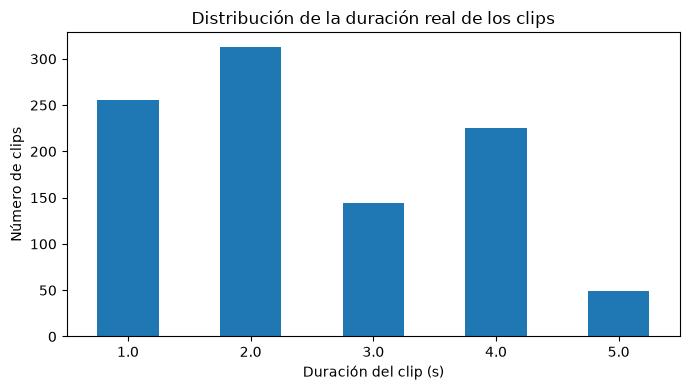

In [7]:
ax = distribucion_duracion.plot(
    x="duracion_s",
    y="clips",
    kind="bar",
    legend=False,
    figsize=(7, 4)
)

ax.set_title("Distribución de la duración real de los clips")
ax.set_xlabel("Duración del clip (s)")
ax.set_ylabel("Número de clips")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
resumen_por_fuente = (
    df.groupby("dataset")
    .agg(
        clips=("nombre_clip", "count"),
        duracion_min_s=("duracion_real_s", "min"),
        duracion_max_s=("duracion_real_s", "max"),
        duracion_media_s=("duracion_real_s", "mean"),
        duracion_mediana_s=("duracion_real_s", "median"),
        clips_4s=("cumple_4s", "sum"),
    )
    .reset_index()
)

resumen_por_fuente["clips_fuera_4s"] = (
    resumen_por_fuente["clips"]
    - resumen_por_fuente["clips_4s"]
)

resumen_por_fuente.round(3)

,dataset,clips,duracion_min_s,duracion_max_s,duracion_media_s,duracion_mediana_s,clips_4s,clips_fuera_4s
0,CCTV_YOLO,8,4.0,4.0,4.000,4.0,8,0
1,DCSASS,783,1.0,5.0,2.098,2.0,21,762
2,MNNIT,182,4.0,4.0,4.000,4.0,182,0
3,SINTETICO,14,4.0,4.0,4.000,4.0,14,0


### 1.7 Diferencias temporales entre fuentes

El análisis por fuente muestra que la variabilidad de duración se concentra en DCSASS. Mientras que CCTV_YOLO, MNNIT y SINTETICO presentan clips de 4 segundos, DCSASS contiene clips con duraciones entre 1 y 5 segundos, con una media de 2.098 segundos.

De los 783 clips de DCSASS, únicamente 21 cumplen aproximadamente con la referencia de 4 segundos y 762 presentan una duración diferente.

Esta diferencia temporal debe considerarse durante la preparación de los datos, ya que la duración podría actuar como una característica asociada al dataset de origen. Para reducir este riesgo, la duración se utilizará como variable de control y se aplicará posteriormente una estrategia de normalización temporal antes del entrenamiento de modelos que requieran entradas uniformes.

In [9]:
df_binario = df[
    df["elegible_modelo_binario"] == True
].copy()

tabla_fuente_clase = pd.crosstab(
    df_binario["dataset"],
    df_binario["etiqueta"]
)

tabla_fuente_clase["total"] = tabla_fuente_clase.sum(axis=1)

tabla_fuente_clase["pct_ocultamiento"] = (
    tabla_fuente_clase["ocultamiento"]
    / tabla_fuente_clase["total"]
    * 100
).round(2)

tabla_fuente_clase

etiqueta,ocultamiento,sin_ocultamiento,total,pct_ocultamiento
dataset,,,,
CCTV_YOLO,4,4,8,50.00
DCSASS,84,699,783,10.73
MNNIT,92,90,182,50.55
SINTETICO,10,2,12,83.33


### 1.8 Distribución de clases por fuente

La distribución de las clases no es uniforme entre las fuentes utilizadas. En CCTV_YOLO y MNNIT aproximadamente la mitad de los clips corresponden a `ocultamiento`, mientras que en DCSASS esta clase representa únicamente el 10.73% y en SINTETICO alcanza el 83.33%.

Estas diferencias indican que existe una asociación entre la fuente de los datos y la variable objetivo. Si un modelo aprende características visuales propias de cada dataset, como resolución, cámara, escenario, iluminación o procesamiento del video, podría utilizarlas como señales indirectas para predecir la clase.

Por esta razón, la variable `dataset` se conservará para control, análisis y definición de particiones experimentales, pero no se utilizará como característica de entrada del modelo. La evaluación posterior deberá comprobar que el desempeño se mantiene cuando se utilizan datos de fuentes distintas a las observadas durante el entrenamiento.

### 1.9 Relación entre duración y etiqueta

Además de analizar las diferencias entre fuentes, se revisó si la duración de los clips presenta alguna asociación con la variable objetivo. Esta comprobación es relevante porque una característica temporal podría convertirse en una señal indirecta para distinguir las clases.

Sin embargo, la relación entre duración y etiqueta debe interpretarse considerando el dataset de origen, ya que las fuentes presentan tanto duraciones como proporciones de clase diferentes. Por ello, primero se analiza la distribución global y posteriormente se revisa el comportamiento dentro de DCSASS, que concentra la variabilidad temporal del conjunto consolidado.

In [10]:
tabla_duracion_clase = pd.crosstab(
    df_binario["duracion_real_s"],
    df_binario["etiqueta"]
)

tabla_duracion_clase["total"] = (
    tabla_duracion_clase.sum(axis=1)
)

tabla_duracion_clase["pct_ocultamiento"] = (
    tabla_duracion_clase["ocultamiento"]
    / tabla_duracion_clase["total"]
    * 100
).round(2)

tabla_duracion_clase

etiqueta,ocultamiento,sin_ocultamiento,total,pct_ocultamiento
duracion_real_s,,,,
1.0,10,246,256,3.91
2.0,54,259,313,17.25
3.0,11,133,144,7.64
4.0,108,115,223,48.43
5.0,7,42,49,14.29


In [11]:
dcsass_binario = df_binario[
    df_binario["dataset"] == "DCSASS"
].copy()

tabla_dcsass_duracion_clase = pd.crosstab(
    dcsass_binario["duracion_real_s"],
    dcsass_binario["etiqueta"]
)

tabla_dcsass_duracion_clase["total"] = (
    tabla_dcsass_duracion_clase.sum(axis=1)
)

tabla_dcsass_duracion_clase["pct_ocultamiento"] = (
    tabla_dcsass_duracion_clase["ocultamiento"]
    / tabla_dcsass_duracion_clase["total"]
    * 100
).round(2)

tabla_dcsass_duracion_clase

etiqueta,ocultamiento,sin_ocultamiento,total,pct_ocultamiento
duracion_real_s,,,,
1.0,10,246,256,3.91
2.0,54,259,313,17.25
3.0,11,133,144,7.64
4.0,2,19,21,9.52
5.0,7,42,49,14.29


### Interpretación de la relación entre duración y etiqueta

En el análisis global se observa una asociación aparente entre la duración de los clips y la clase. Por ejemplo, los clips de 4 segundos presentan 48.43% de `ocultamiento`.

Sin embargo, al analizar únicamente DCSASS, la proporción de `ocultamiento` en clips de 4 segundos disminuye a 9.52%. Esta diferencia indica que la relación global entre duración y etiqueta está condicionada por el dataset de origen.

La fuente funciona como una variable de confusión, ya que está asociada tanto con la duración de los clips como con la distribución de las clases. Además, dentro de DCSASS no se observa una tendencia monotónica entre duración y porcentaje de `ocultamiento`.

Por esta razón, la duración no se utilizará como característica predictora directa del modelo. Se conservará como variable de control para la preparación de los datos y para definir la normalización temporal requerida antes del entrenamiento.

### 1.10 Codificación de la variable objetivo

Para preparar el problema de clasificación binaria se generó la característica `clase_binaria` a partir de la etiqueta original de cada clip.

La codificación utilizada es:

- `sin_ocultamiento` = **0**
- `ocultamiento` = **1**

Los clips con etiqueta `ambiguo` se conservan en el dataset consolidado para fines de análisis, pero no reciben una clase numérica y se marcan como no elegibles para el entrenamiento binario. Esta decisión evita introducir ruido de etiqueta asignando de forma artificial una clase a observaciones cuya acción no puede determinarse con suficiente claridad.

In [12]:
tabla_codificacion = pd.crosstab(
    df["etiqueta"],
    df["clase_binaria"],
    dropna=False
)

tabla_codificacion

clase_binaria,0.0,1.0,NaN
etiqueta,,,
ambiguo,0,0,2
ocultamiento,0,190,0
sin_ocultamiento,795,0,0


#### Verificación de la codificación

La comprobación de la variable objetivo confirmó que los 795 clips etiquetados como `sin_ocultamiento` fueron codificados como clase 0 y los 190 clips de `ocultamiento` como clase 1.

Los 2 clips etiquetados como `ambiguo` permanecen sin asignación numérica y no son elegibles para el entrenamiento binario. De esta manera, la codificación conserva la información original del etiquetado y evita introducir ruido al forzar observaciones inciertas dentro de alguna de las dos clases.

### 1.11 Conclusiones de la construcción de características

La consolidación permitió integrar 987 clips provenientes de cuatro fuentes y conservar la trazabilidad de cada observación mediante su dataset de origen, identificadores y etiqueta original.

A partir de los archivos físicos y del manifiesto se generaron nuevas características relacionadas con duración real, cumplimiento de la duración objetivo, necesidad de normalización temporal, elegibilidad para el problema binario y codificación de la variable objetivo.

El análisis mostró diferencias importantes entre las fuentes. DCSASS concentra la variabilidad temporal y representa la mayor parte del dataset, mientras que la proporción de `ocultamiento` también cambia de forma considerable entre fuentes. Además, la relación observada entre duración y etiqueta está condicionada por el dataset de origen.

Por estas razones, variables como `dataset` y `duracion_real_s` se conservarán para control, auditoría y preparación de los experimentos, pero no se utilizarán directamente como características predictoras del modelo RGB. La siguiente etapa se enfocará en normalizar las entradas para reducir diferencias asociadas con la duración y la representación de los videos.